In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import skew

# ------------------------------------------------------------
# 1. LOAD & BASIC CLEANING
# ------------------------------------------------------------
df = pd.read_csv('v3_master_combined.csv') 

df = df.drop("Brand Name", axis=1)
df = df.drop(columns=["Total_Sale_Normalized"])

df = df.dropna(subset=["Total Sale"])

# uncomment if loading fresh

df["Date"] = pd.to_datetime(df["Date"])
df = df.drop_duplicates()


if "total_sale_normalized" in df.columns:
    df = df.drop(columns=["total_sale_normalized"])

df = df.drop(columns=[c for c in ["postcode", "outercode"] if c in df.columns])


# Keep only the real, continuous data window (drops unrelated 2010-2013 branches)
df = df[df["Date"].dt.year >= 2020].copy()

df = df.dropna(subset=["Total Sale"])

# ------------------------------------------------------------
# 2. LAG / ROLLING FEATURES (per branch)
# ------------------------------------------------------------
df = df.sort_values(["Branch Name", "Date"]).reset_index(drop=True)

df["sales_lag_1"] = df.groupby("Branch Name")["Total Sale"].shift(1)
df["sales_lag_7"] = df.groupby("Branch Name")["Total Sale"].shift(7)
df["sales_roll_7_mean"] = (
    df.groupby("Branch Name")["Total Sale"]
    .shift(1)
    .rolling(7)
    .mean()
    .reset_index(0, drop=True)
)
df["sales_roll_30_mean"] = (
    df.groupby("Branch Name")["Total Sale"]
    .shift(1)
    .rolling(30)
    .mean()
    .reset_index(0, drop=True)
)
df["branch_dow_avg"] = df.groupby(["Branch Name", "Day_of_Week"])[
    "Total Sale"
].transform(lambda x: x.shift(1).expanding().mean())

lag_cols = [
    "sales_lag_1",
    "sales_lag_7",
    "sales_roll_7_mean",
    "sales_roll_30_mean",
    "branch_dow_avg",
]
df = df.dropna(subset=lag_cols)

# Re-sort by date only, now that lag features are computed
df = df.sort_values("Date").reset_index(drop=True)


# ------------------------------------------------------------
# 3. MULTICOLLINEARITY CHECK (drop features correlated > 0.95)
# ------------------------------------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns.drop(
    "Total Sale", errors="ignore"
)
corr_matrix = df[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print("Dropping (multicollinearity):", to_drop)
df = df.drop(columns=to_drop)


# ------------------------------------------------------------
# 4. TEMPORAL TRAIN/TEST SPLIT
# ------------------------------------------------------------
split_date = df["Date"].quantile(0.8, interpolation="nearest")

train = df[df["Date"] < split_date].copy()
test = df[df["Date"] >= split_date].copy()

print(f"Train: {train['Date'].min()} to {train['Date'].max()} ({len(train)} rows)")
print(f"Test:  {test['Date'].min()} to {test['Date'].max()} ({len(test)} rows)")

X_train = train.drop(columns=["Total Sale", "Date"])
y_train = train["Total Sale"]
X_test = test.drop(columns=["Total Sale", "Date"])
y_test = test["Total Sale"]


# ------------------------------------------------------------
# 5. ENCODING
# ------------------------------------------------------------
encoder = TargetEncoder(cols=["Branch Name"])
X_train["Branch Name"] = encoder.fit_transform(X_train["Branch Name"], y_train)
X_test["Branch Name"] = encoder.transform(X_test["Branch Name"])

categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
print("One-hot encoding:", categorical_cols)
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(
    "NaNs -> X_train:",
    X_train.isnull().sum().sum(),
    "| X_test:",
    X_test.isnull().sum().sum(),
)


# ------------------------------------------------------------
# 6. SCALING
# ------------------------------------------------------------
numeric_features = X_train.select_dtypes(include="number").columns.tolist()

constant_cols = [c for c in numeric_features if X_train[c].nunique() <= 1]
X_train = X_train.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)
numeric_features = [c for c in numeric_features if c not in constant_cols]

binary_cols = [c for c in numeric_features if X_train[c].dropna().isin([0, 1]).all()]
continuous_cols = [c for c in numeric_features if c not in binary_cols]

skew_vals = X_train[continuous_cols].apply(lambda x: skew(x.dropna()))
standard_cols = skew_vals[abs(skew_vals) < 0.5].index.tolist()
robust_cols = skew_vals[abs(skew_vals) >= 0.5].index.tolist()

standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

X_train[standard_cols] = standard_scaler.fit_transform(X_train[standard_cols])
X_test[standard_cols] = standard_scaler.transform(X_test[standard_cols])

X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])


# ------------------------------------------------------------
# 7. BASELINE MODELS
# ------------------------------------------------------------
baselines = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

results = []
for name, model in baselines.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append(
        {
            "Model": name,
            "MAE": mean_absolute_error(y_test, preds),
            "MSE": mean_squared_error(y_test, preds),
            "R2": r2_score(y_test, preds),
        }
    )

results_df = pd.DataFrame(results)
print("\n=== Results ===")
print(results_df)

importances = pd.Series(
    baselines["GradientBoosting"].feature_importances_, index=X_train.columns
)
print("\n=== Top 15 Feature Importances ===")
print(importances.sort_values(ascending=False).head(15))


Dropping (multicollinearity): ['working', 'unemployed', 'non-white', 'Transport_Accessibility_Score', 'distance_to_nearest_station_mi', 'sales_roll_30_mean']
Train: 2020-01-31 00:00:00 to 2024-10-13 00:00:00 (44139 rows)
Test:  2024-10-14 00:00:00 to 2025-06-30 00:00:00 (11078 rows)
One-hot encoding: ['Day_of_Week', 'Nearest_Station_Type', 'Dataset', 'Inferred_Brand']
NaNs -> X_train: 0 | X_test: 0

=== Results ===
              Model         MAE           MSE        R2
0  LinearRegression  161.534962  68220.757701  0.754461
1      RandomForest  155.543933  61403.157223  0.778999
2  GradientBoosting  152.491989  59242.557946  0.786776

=== Top 15 Feature Importances ===
sales_roll_7_mean              0.684283
sales_lag_7                    0.156987
sales_lag_1                    0.089072
branch_dow_avg                 0.048604
is_weekend                     0.004837
Day_of_Week_Sunday             0.003279
is_ramadan                     0.001703
Branch Name                    0.001130
D

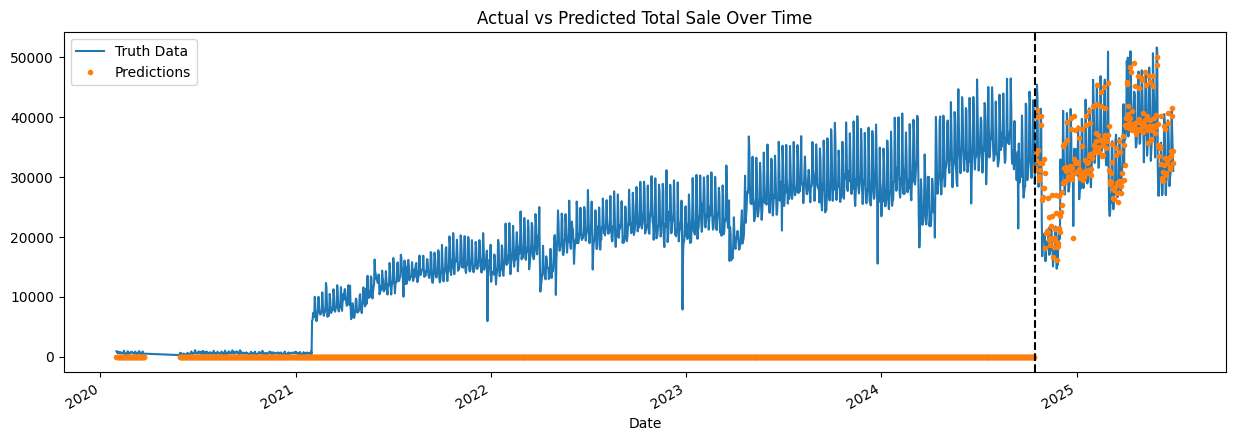

In [5]:
# Attach predictions to the test set
test = test.copy()
test["prediction"] = baselines["GradientBoosting"].predict(X_test)

# Merge predictions back into the full df, aligned by index
df_plot = df.merge(test[["prediction"]], how="left", left_index=True, right_index=True)

# Aggregate to daily totals (since you have multiple branches per day, like before)
daily_actual = df_plot.groupby("Date")["Total Sale"].sum()
daily_pred = df_plot.groupby("Date")["prediction"].sum()

fig, ax = plt.subplots(figsize=(15, 5))
daily_actual.plot(ax=ax, label="Truth Data")
daily_pred.plot(ax=ax, style=".", label="Predictions")
ax.axvline(split_date, color="black", ls="--")
ax.legend(["Truth Data", "Predictions"])
ax.set_title("Actual vs Predicted Total Sale Over Time")
plt.show()


In [6]:
target_mean = np.mean(y_train)
print(f"Target Average: {target_mean}")


Target Average: 703.42949636376


# **Till Now Code is Perfect**